# 0. Import libraries

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from einops import rearrange
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.eval_util.plot import plot_single, plot_next_multi
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# 1. Forecasting with Moirai

<img src="img/pred_def.png" alt="Drawing" style="width: 800px;"/>

Given a time series, Moirai (prediction model) use the context window as input and outputs a prediction window. So, the user need to set the **context_length** and **prediction_length** in advance. 

For time series data, the information contained within a single timestamp is not rich enough. Therefore, we refer to consecutive time points as 'patches', forming the basic units of Moirai input (similar to the concept of word token in Language Models). Moirai provides various ***patch_size*** [8, 16, 32, 64, 128].

Additionally, users need to select the **model size** ('small', 'base', 'large') of Moirai for prediction, along with the **batch_size**, which determines the number of samples that can be inferred in parallel. Since Moirai supports probablistic forecast, users should specify the **num_samples**, indicating the number of times it has to sample the forecasting distribution.

Original dataframe
                     target item_id
2021-01-01 00:00:00 -1.3378       A
2021-01-01 01:00:00 -1.6111       A
2021-01-01 02:00:00 -1.9259       A
2021-01-01 03:00:00 -1.9184       A
2021-01-01 04:00:00 -1.9168       A


Shape of dataframe: (240, 1)
total length: 240
time frequency: 0 days 01:00:00


<Axes: >

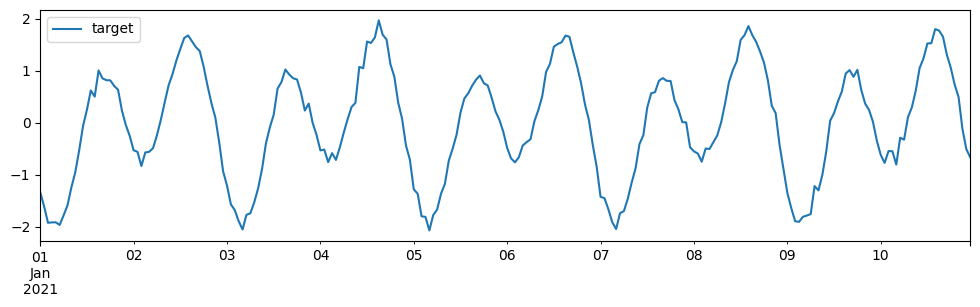

In [41]:
# Load dataframe and plot it
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)
df = pd.read_csv(url, index_col=0, parse_dates=True)
print(f"Original dataframe")
print(df.head())
print('\n')
df = df[df["item_id"] == "A"].drop(columns=["item_id"])
print(f"Shape of dataframe: {df.shape}")
print(f"total length: {df.shape[0]}")
print(f"time frequency: {df.index.diff()[1]}")
df.plot(figsize=(12, 3))

In [42]:
# Create a sample for the hourly data, using one week of data as the context window and predicting the next two days.
inp = {
    "target": df["target"].to_numpy()[:168],  # Use the first 168 data points (24 hours * 7 days = 168), representing one week of data.
    "start": df.index[0].to_period(freq="H"),  # Set the start time for the context window using the first index in hourly periods.
}
label = {
    "target": df["target"].to_numpy()[168:216],  # Use the next 48 data points (24 hours * 2 days = 48) for the target, representing the next two days.
    "start": df.index[168].to_period(freq="H"),  # Set the start time for the label using the index at position 168 in hourly periods.
}


In [43]:
from transformers import AutoModel  # "pip install transformers" 필요
# model = AutoModel.from_pretrained("Salesforce/moirai-1.1-R-small")
# Prepare model
# Initialize the MoiraiForecast model with the specified parameters
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.1-R-small"),  # Load the pretrained Moirai model
    prediction_length=48,  # Length of the prediction window (next 48 hours)
    context_length=168,  # Length of the context window (previous 168 hours, one week)
    patch_size=32,  # Size of the input patch (used internally by the model)
    num_samples=100,  # Number of samples used for probabilistic forecasting
    target_dim=1,  # Dimension of the target variable (1D, single variate time series)
    feat_dynamic_real_dim=0,  # No dynamic real-valued features used in this model
    past_feat_dynamic_real_dim=0,  # No past dynamic real-valued features used
)

# Reshape the past target (context window) values. Shape: (batch, time, variate)
# `inp["target"]` is reshaped from (time) to (1, time, 1), indicating a single batch and single time series variable
past_target = rearrange(
    torch.as_tensor(inp["target"], dtype=torch.float32), "t -> 1 t 1"
)
print(f"Shape of 'past_target': {past_target.shape}")

# Create a mask for observed values. All values are set to 1 (True), indicating all values are observed. 
# Shape: (batch, time, variate)
past_observed_target = torch.ones_like(past_target, dtype=torch.bool)
print(f"Shape of 'past_observed_target': {past_observed_target.shape}")

# Create a padding mask. All values are set to 0 (False), meaning no padding is used.
# Shape: (batch, time). The squeeze removes the last dimension since padding only applies to time.
past_is_pad = torch.zeros_like(past_target, dtype=torch.bool).squeeze(-1)
print(f"Shape of 'past_is_pad': {past_is_pad.shape}")

# Generate the forecast using the model. The past target, observed target mask, and padding mask are passed as inputs.
forecast = model(
    past_target=past_target,  # Past time series values (context window)
    past_observed_target=past_observed_target,  # Mask indicating which values are observed
    past_is_pad=past_is_pad,  # Mask indicating whether padding is applied (False here, no padding)
)
print(f"Shape of 'forecast': {forecast.shape}")  # 100 개의 확률적인 예측 결과 출력

Shape of 'past_target': torch.Size([1, 168, 1])
Shape of 'past_observed_target': torch.Size([1, 168, 1])
Shape of 'past_is_pad': torch.Size([1, 168])
Shape of 'forecast': torch.Size([1, 100, 48])


In [44]:
# 확률적인 예측 결과(48시간 예측 결과) 100개의 median을 실제 label(48시간 실제 결과)과 비교
print(
    "median prediction:\n",
    np.round(np.median(forecast[0], axis=0), decimals=4),
)
print("ground truth:\n", label["target"])

median prediction:
 [-1.1972 -1.5765 -1.8682 -2.0375 -1.922  -1.7791 -1.5787 -1.3968 -1.265
 -0.9799 -0.8279 -0.5008 -0.098   0.2578  0.4306  0.5688  0.4824  0.5801
  0.4935 -0.0666 -0.1846 -0.3795 -0.593  -1.0518 -1.3928 -1.6356 -1.9153
 -1.9933 -2.0816 -1.7589 -1.538  -1.3834 -1.3887 -0.887  -0.9293 -0.5182
  0.0927 -0.0568  0.1655  0.1417  0.0837  0.4885  0.2049 -0.0816 -0.1354
 -0.9772 -1.1098 -1.3188]
ground truth:
 [-0.5511 -0.5932 -0.7505 -0.4978 -0.5051 -0.3753 -0.244   0.0095  0.3692
  0.7807  1.0135  1.1805  1.5927  1.6855  1.8593  1.685   1.5527  1.3677
  1.1558  0.8158  0.3267  0.1822 -0.427  -0.8917 -1.3495 -1.6403 -1.8952
 -1.9084 -1.8111 -1.7865 -1.7594 -1.2197 -1.3027 -1.0029 -0.5541  0.037
  0.1842  0.4091  0.5988  0.9457  1.0123  0.8828  1.0167  0.6306  0.3671
  0.2454  0.0181 -0.3464]


# 2. Rolling Evaluation

<img src="img/rolling_eval.png" alt="Drawing" style="width: 800px;"/>

As shown in the above plot, we use GluonTS to construct rolling window evaluation

## Settings
SIZE: model size, select the model size of Moirai to perform inference with

PDT: prediction length, how many time steps to predict into the future

CTX: context length, how many time steps the model will take as input for inference

PSZ: patch size, how many time steps to perform patching with

BSZ: batch size, number of samples in each batch for inference

TEST: test set length, number of time steps to hold out for test set

In [45]:
SIZE = "small"  # model size: choose from {'small', 'base', 'large'}
PDT = 20  # prediction length: any positive integer
CTX = 200  # context length: any positive integer
PSZ = "auto"  # patch size: choose from {"auto", 8, 16, 32, 64, 128}
BSZ = 32  # batch size: any positive integer
TEST = 100  # test set length: any positive integer

## 2.1 Loading from a _long_ DataFrame (종으로 긴 DataFrame인 경우)

In [50]:
# Load dataframe
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)
df = pd.read_csv(url, index_col=0, parse_dates=True)
print(f"Original dataframe shape: {df.shape}")
df

Original dataframe shape: (2400, 2)


,target,item_id
2021-01-01 00:00:00,-1.3378,A
2021-01-01 01:00:00,-1.6111,A
2021-01-01 02:00:00,-1.9259,A
2021-01-01 03:00:00,-1.9184,A
2021-01-01 04:00:00,-1.9168,A
...,...,...
2021-01-10 19:00:00,1.2349,J
2021-01-10 20:00:00,1.1525,J
2021-01-10 21:00:00,1.1485,J
2021-01-10 22:00:00,1.3248,J


In [47]:
# Convert into GluonTS dataset
# target: Specifies the column name in df that contains the target values (the values you are trying to forecast)
# item_id: Specifies the column name in df that contains the unique identifier for different items
ds = PandasDataset.from_long_dataframe(df, target="target", item_id="item_id")

# Check the dataset stored in variable 'ds' using iterator
# item_id를 기준으로 데이터셋이 나누어져 ds에 저장됨
# for idx, entry in enumerate(ds):
#     print(idx)
#     print(entry)  # --- A부터 J까지 loop를 돌면서 확인 가능 (총 루프 10회)
#     print(entry["target"].shape)
    
# Split into train/test set
train, test_template = split(
    ds, offset=-TEST
)  # assign last TEST time steps as test set

# Construct rolling window evaluation
test_data = test_template.generate_instances(
    prediction_length=PDT,  # number of time steps for each prediction
    windows=TEST // PDT,  # number of windows in rolling window evaluation
    distance=PDT,  # number of time steps between each window (distance=PDT for non-overlapping windows / distance가 PDT와 동일한 경우 overlapping 없음)
)

# Check the ds.num_feat_dynamic_real
# ds.num_feat_dynamic_real: 미래 시점에서 사용할 추가적인(참고할 수 있는 외부 변수) 동적 실수형 피처들의 수를 의미 (0이면 없다는 것!)
print(f"Check the ds.num_feat_dynamic_real: {ds.num_feat_dynamic_real}")

# Check the ds.num_past_feat_dynamic_real
# ds.num_past_feat_dynamic_real: 과거 시점에서 사용된 추가적인(참고할 수 있는 외부 변수) 동적 실수형 피처들의 수를 의미 (0이면 없다는 것!)
print(f"Check the ds.num_past_feat_dynamic_real: {ds.num_past_feat_dynamic_real}")

Check the ds.num_feat_dynamic_real: 0
Check the ds.num_past_feat_dynamic_real: 0


In [48]:
# Prepare the MoiraiForecast model with the given parameters
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-small"),  # Load the pre-trained Moirai module
    prediction_length=PDT,  # Set the length of the prediction window (number of future time steps to forecast)
    context_length=CTX,  # Set the length of the context window (number of past time steps used to make predictions)
    patch_size=PSZ,  # Define the size of input patches, which can help process time series data in segments
    num_samples=100,  # Number of samples generated for probabilistic forecasting (more samples increase reliability)
    target_dim=1,  # The dimension of the target variable (1 indicates univariate forecasting)
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,  # The dimension of dynamic real-valued features (external covariates) from the dataset
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,  # The dimension of past dynamic real-valued features from the dataset
)

# Create the predictor instance with the specified batch size
predictor = model.create_predictor(batch_size=BSZ)  # Create a predictor object with a defined batch size (BSZ) for batch processing

# Use the predictor to generate forecasts on the test data
forecasts = predictor.predict(test_data.input)  # Generate predictions (forecasts) based on the input data (past observations)

# Create iterators for the input, label, and forecast data
input_it = iter(test_data.input)  # Create an iterator for the input data (context window)
label_it = iter(test_data.label)  # Create an iterator for the label data (true future values, for evaluation purposes)
forecast_it = iter(forecasts)  # Create an iterator for the forecasted data (predicted future values)

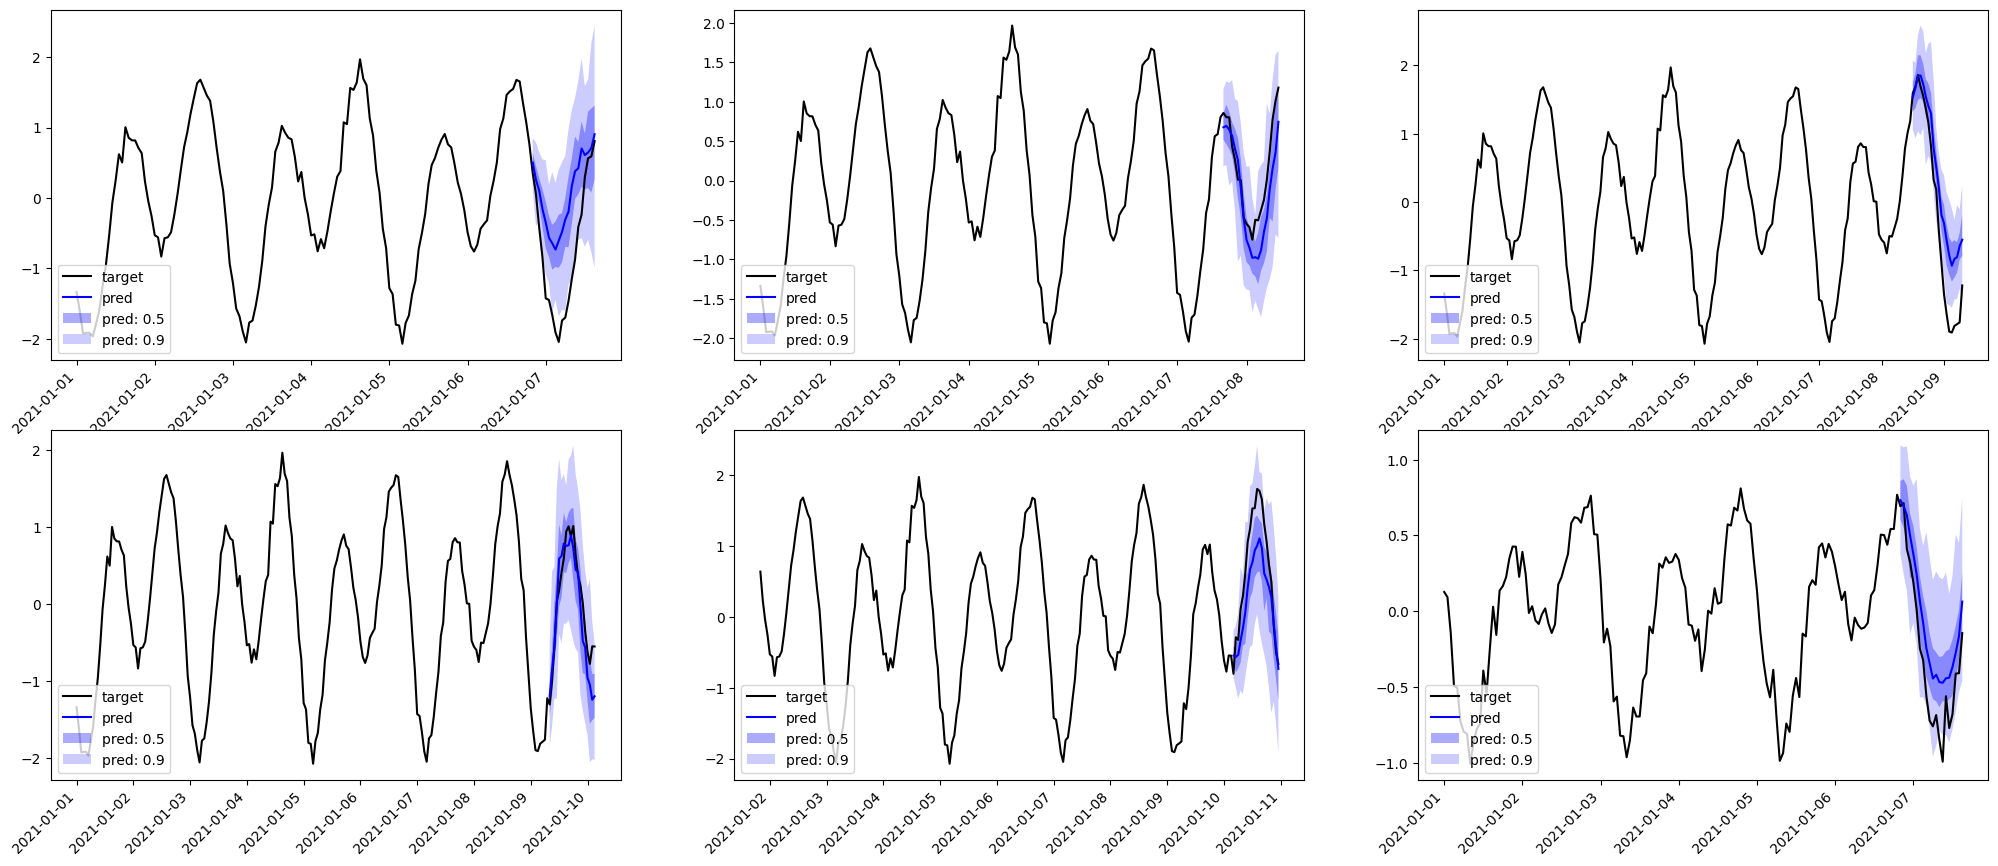

In [49]:
# Make predictions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
plot_next_multi(
    axes,
    input_it,
    label_it,
    forecast_it,
    context_length=200,
    intervals=(0.5, 0.9),
    dim=None,
    name="pred",
    show_label=True,
)

## 2.2 Loading from a _wide_ DataFrame (횡으로 넓은 DataFrame인 경우)

In [51]:
# Load dataframe
url_wide = (
    "https://gist.githubusercontent.com/rsnirwan/c8c8654a98350fadd229b00167174ec4"
    "/raw/a42101c7786d4bc7695228a0f2c8cea41340e18f/ts_wide.csv"
)
df = pd.read_csv(url_wide, index_col=0, parse_dates=True)

df.head()

,A,B,C,D,E,F,G,H,I,J
2021-01-01 00:00:00,-1.3378,0.1268,-0.3645,-1.0864,-2.3803,-0.2447,2.2647,-0.7917,0.7071,1.3763
2021-01-01 01:00:00,-1.6111,0.0926,-0.1364,-1.1613,-2.1421,-0.3477,2.4262,-0.9609,0.6413,1.2750
2021-01-01 02:00:00,-1.9259,-0.1420,0.1063,-1.0405,-2.1426,-0.3271,2.4434,-0.9034,0.4323,0.6767
2021-01-01 03:00:00,-1.9184,-0.4930,0.6269,-0.8531,-1.7060,-0.3088,2.4307,-0.9602,0.3193,0.5150
2021-01-01 04:00:00,-1.9168,-0.5057,0.9419,-0.7666,-1.4287,-0.4284,2.3258,-1.2504,0.3660,0.1708


In [16]:
# Convert into GluonTS dataset
ds = PandasDataset(dict(df))

# Split into train/test set
train, test_template = split(
    ds, offset=-TEST
)  # assign last TEST time steps as test set

# Construct rolling window evaluation
test_data = test_template.generate_instances(
    prediction_length=PDT,  # number of time steps for each prediction
    windows=TEST // PDT,  # number of windows in rolling window evaluation
    distance=PDT,  # number of time steps between each window - distance=PDT for non-overlapping windows
)

In [17]:
# Prepare model
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-small"),
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

predictor = model.create_predictor(batch_size=BSZ)
forecasts = predictor.predict(test_data.input)

input_it = iter(test_data.input)
label_it = iter(test_data.label)
forecast_it = iter(forecasts)

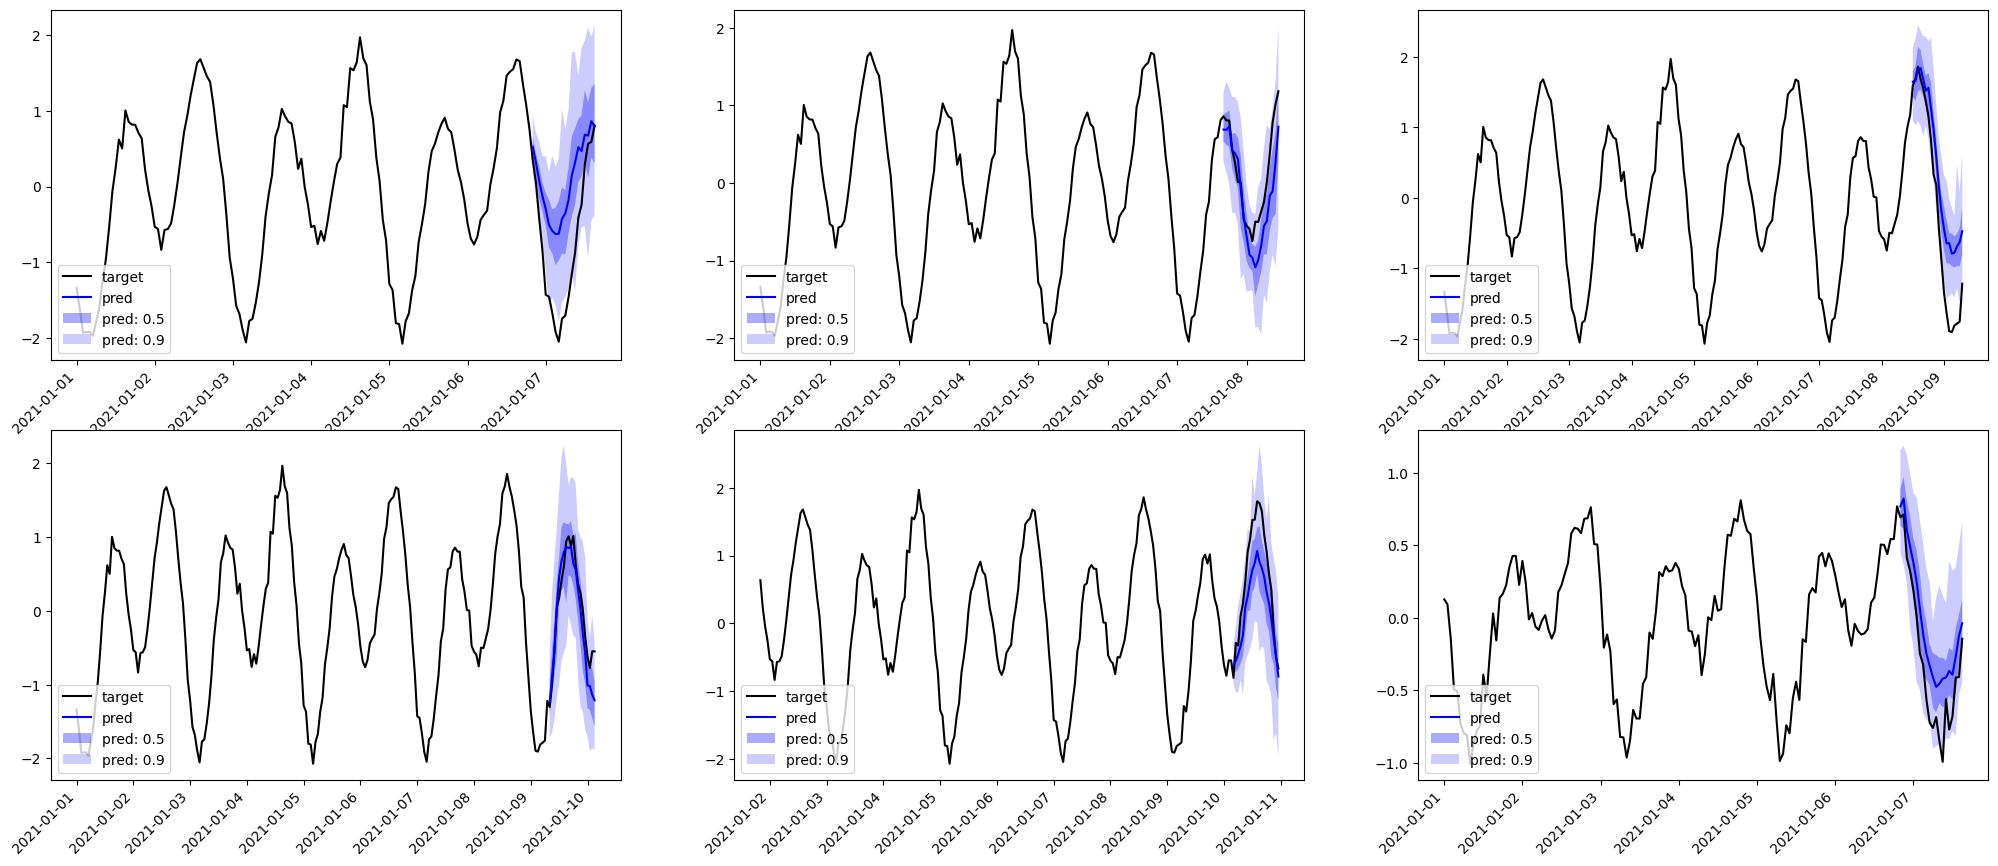

In [18]:
# Make predictions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
plot_next_multi(
    axes,
    input_it,
    label_it,
    forecast_it,
    context_length=200,
    intervals=(0.5, 0.9),
    dim=None,
    name="pred",
    show_label=True,
)

# 2.3 Multivariate Forecasting

In [65]:
# Load dataframe
url_wide = (
    "https://gist.githubusercontent.com/rsnirwan/c8c8654a98350fadd229b00167174ec4"
    "/raw/a42101c7786d4bc7695228a0f2c8cea41340e18f/ts_wide.csv"
)
df = pd.read_csv(url_wide, index_col=0, parse_dates=True)

In [66]:
# Convert into GluonTS dataset
ds = PandasDataset(dict(df))

# Group time series into multivariate dataset
grouper = MultivariateGrouper(len(ds))
multivar_ds = grouper(ds)

# Split into train/test set
train, test_template = split(
    multivar_ds, offset=-TEST
)  # assign last TEST time steps as test set

# Construct rolling window evaluation
test_data = test_template.generate_instances(
    prediction_length=PDT,  # number of time steps for each prediction
    windows=TEST // PDT,  # number of windows in rolling window evaluation
    distance=PDT,  # number of time steps between each window - distance=PDT for non-overlapping windows
)

In [67]:
# Prepare model
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-small"),
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=100,
    target_dim=len(ds),
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

predictor = model.create_predictor(batch_size=BSZ)
forecasts = predictor.predict(test_data.input)

input_it = iter(test_data.input)
label_it = iter(test_data.label)
forecast_it = iter(forecasts)

In [68]:
# Make predictions
inp = next(input_it)
label = next(label_it)
forecast = next(forecast_it)

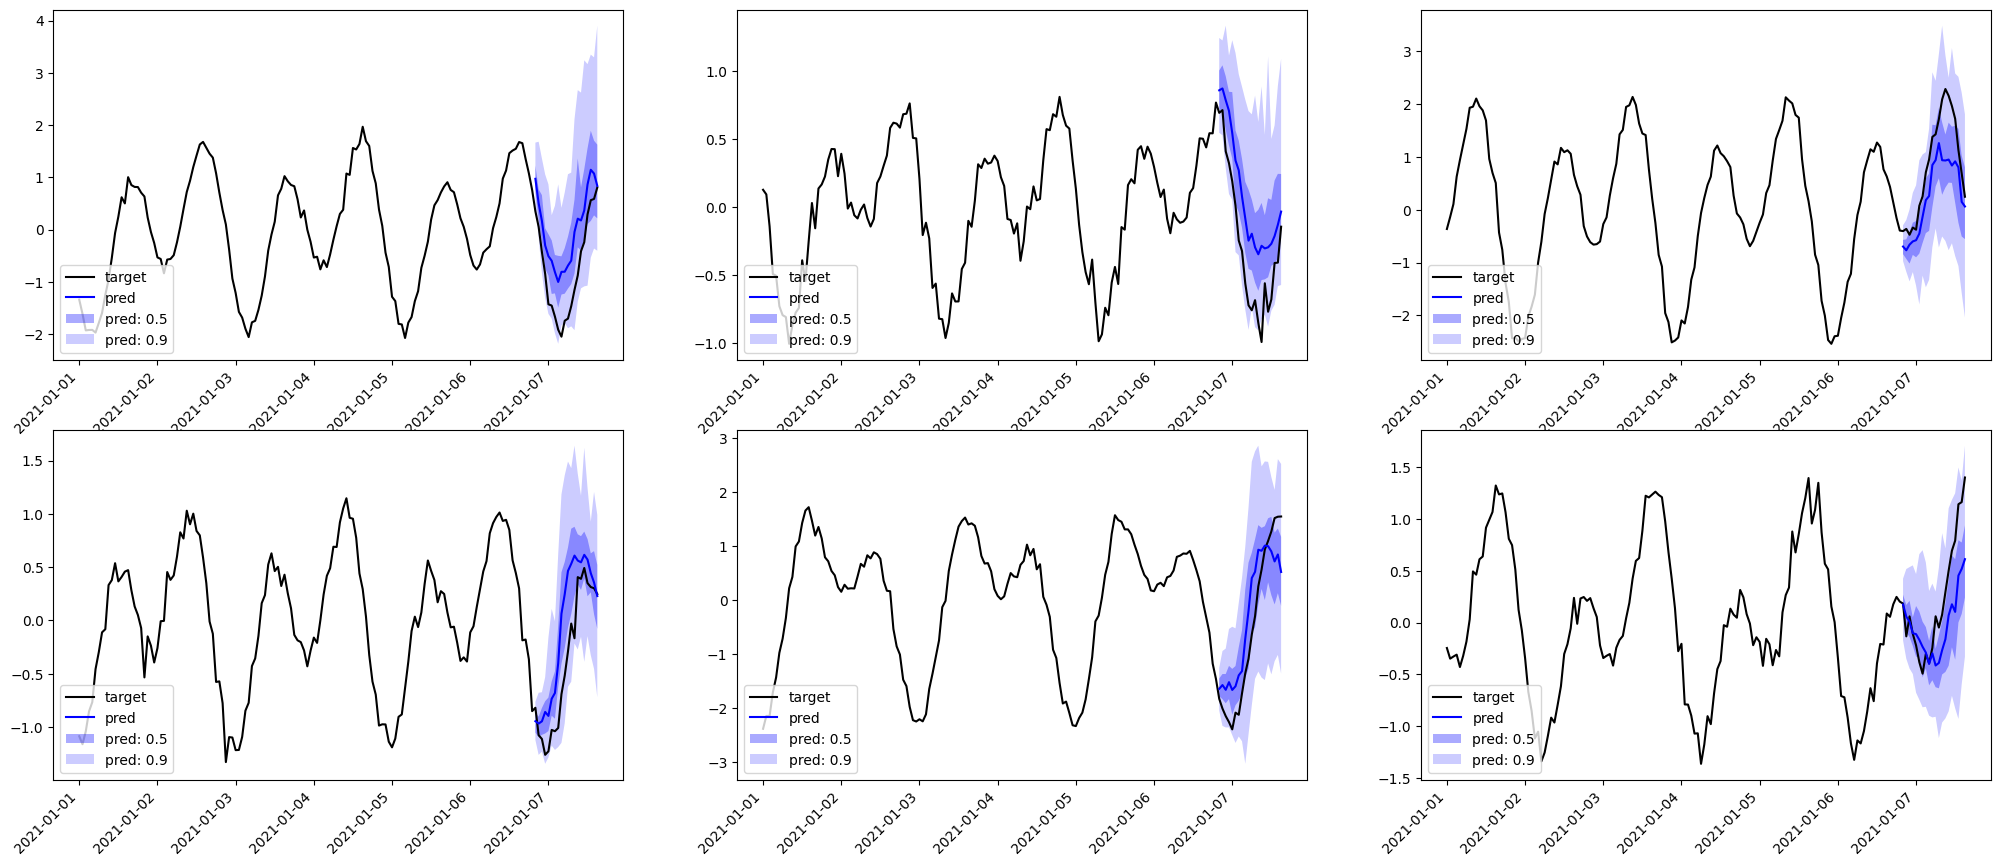

In [69]:
# Visualize different dimensions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
for i, ax in enumerate(axes.flatten()):
    plot_single(
        inp,
        label,
        forecast,
        context_length=200,
        intervals=(0.5, 0.9),
        dim=i,
        ax=ax,
        name="pred",
        show_label=True,
    )

## 2.4 Include dynamic features

<img src="img/extra_feature.png" alt="Drawing" style="width: 800px;"/>

Moirai supports adding additional covariates. Specifically, it could include past dynamic real features, and dynamic real feature that include features in the prediction window.

In [70]:
# Load dataframe
url = (
    "https://gist.githubusercontent.com/rsnirwan/a8b424085c9f44ef2598da74ce43e7a3"
    "/raw/b6fdef21fe1f654787fa0493846c546b7f9c4df2/ts_long.csv"
)
df = pd.read_csv(url, index_col=0, parse_dates=True)
T = df.shape[0]
df["dynamic_real_1"] = np.random.normal(size=T)
df["past_dynamic_real_2"] = np.random.normal(size=T)

In [71]:
ds = PandasDataset.from_long_dataframe(
    df,
    item_id="item_id",
    past_feat_dynamic_real=["past_dynamic_real_2"],
    feat_dynamic_real=["dynamic_real_1"],
)

# Split into train/test set
train, test_template = split(
    ds, offset=-TEST
)  # assign last TEST time steps as test set

# Construct rolling window evaluation
test_data = test_template.generate_instances(
    prediction_length=PDT,  # number of time steps for each prediction
    windows=TEST // PDT,  # number of windows in rolling window evaluation
    distance=PDT,  # number of time steps between each window - distance=PDT for non-overlapping windows
)

In [72]:
# Prepare model
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-small"),
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

predictor = model.create_predictor(batch_size=BSZ)
forecasts = predictor.predict(test_data.input)

input_it = iter(test_data.input)
label_it = iter(test_data.label)
forecast_it = iter(forecasts)

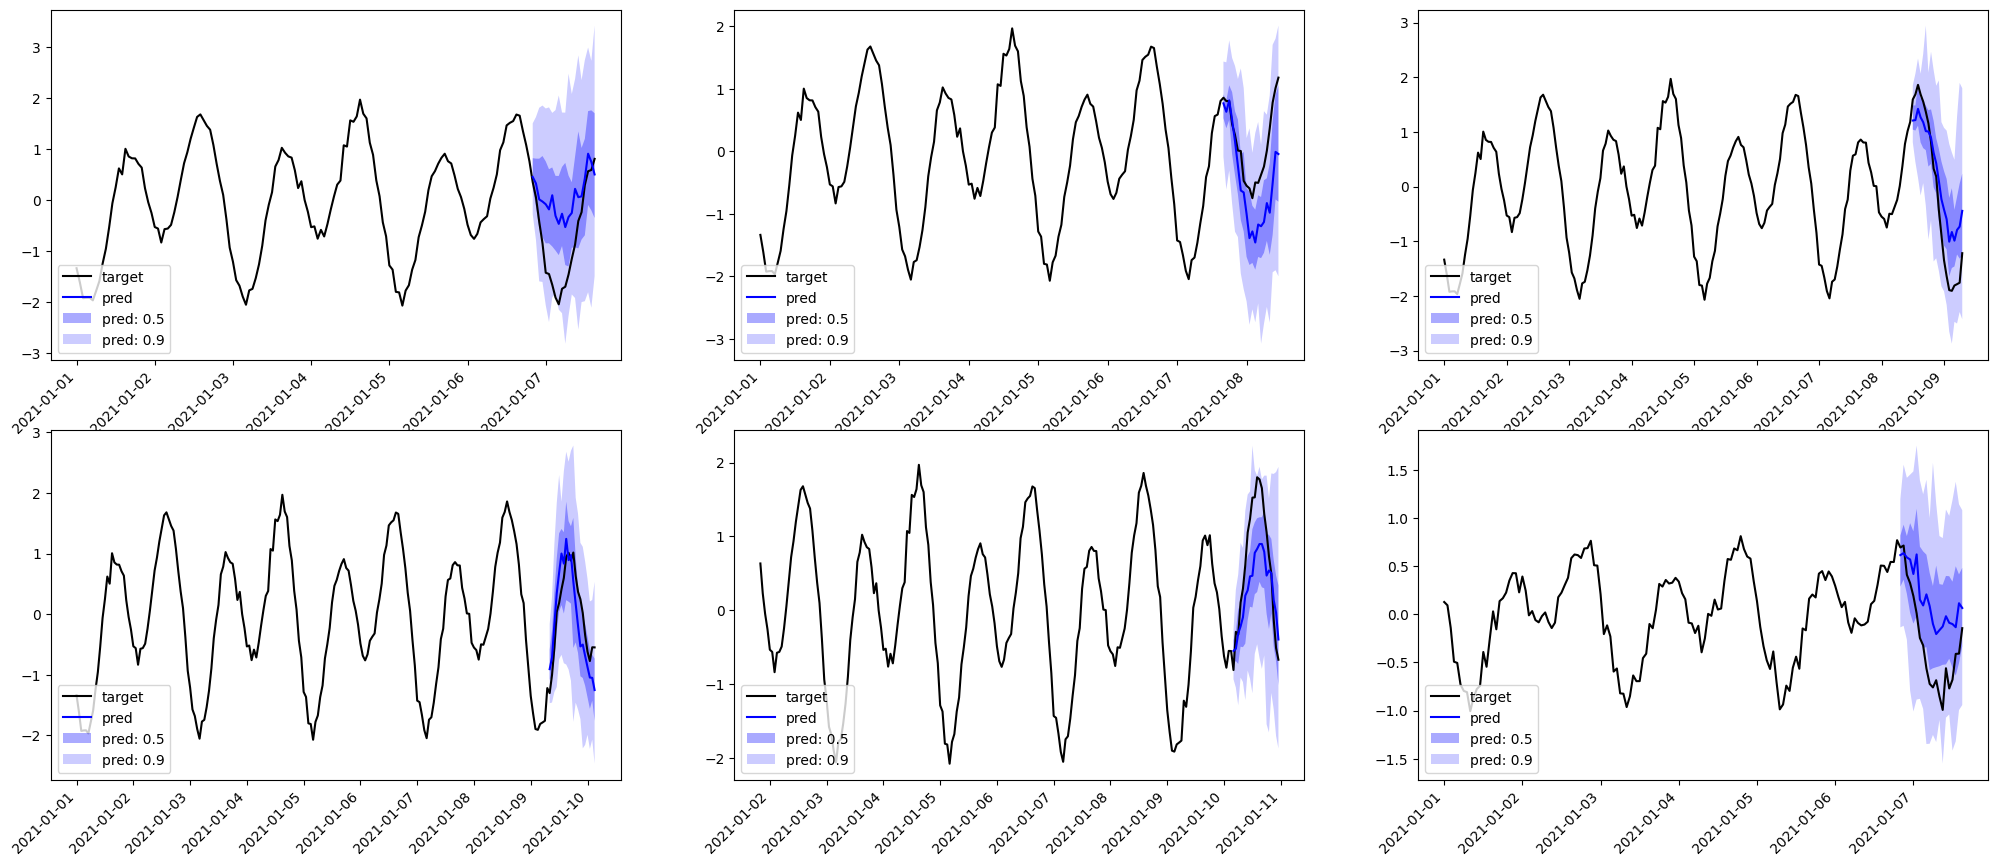

In [73]:
# Make predictions
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(25, 10))
plot_next_multi(
    axes,
    input_it,
    label_it,
    forecast_it,
    context_length=200,
    intervals=(0.5, 0.9),
    dim=None,
    name="pred",
    show_label=True,
)